<a href="https://colab.research.google.com/github/Mrinal0044/Machine-Learning/blob/main/email_spam_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')


In [5]:
df.shape

(5572, 5)

1. data cleaning
2. EDA
3. text preprocessing
4. model building
5. evaluation
6. improvement
7. website
8. deploy

**1.DATA** **CLEANING**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


here we can see that last 3 columns are filled with null values , so we dont need them , DROP THEM

In [7]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3' , 'Unnamed: 4'], inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   v1      5572 non-null   object
 1   v2      5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [9]:
df.sample(5)

,v1,v2
4148,ham,Haven't found a way to get another app for you...
4834,ham,"OH RITE. WELL IM WITH MY BEST MATE PETE, WHO I..."
2752,ham,Sat right? Okay thanks...
2773,spam,How come it takes so little time for a child w...
2806,spam,December only! Had your mobile 11mths+? You ar...


renaming the columns

In [10]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True) #inplace true means for permanent changes

In [11]:
df.sample(6)

,target,text
5399,ham,And he's apparently bffs with carly quick now
1843,ham,Super da:)good replacement for murali
2157,ham,Sad story of a Man - Last week was my b'day. M...
4883,ham,For many things its an antibiotic and it can b...
2063,spam,"URGENT! Your mobile No *********** WON a å£2,0..."
2680,ham,Solve d Case : A Man Was Found Murdered On &l...


In [12]:
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()

In [13]:
df['target']=encoder.fit_transform(df['target'])

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


checking missing values

In [15]:
df.isnull().sum()

,0
target,0
text,0


checking for duplicate values

In [16]:
df.duplicated().sum()

np.int64(403)

there are 403 duplicate values -> remove them

In [17]:
df= df.drop_duplicates(keep='first') #drop duplicates except for first occurence

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(5169, 2)

**2. EDA**

In [20]:
#checking the number of spam vs ham values
df['target'].value_counts()

,count
target,
0,4516
1,653


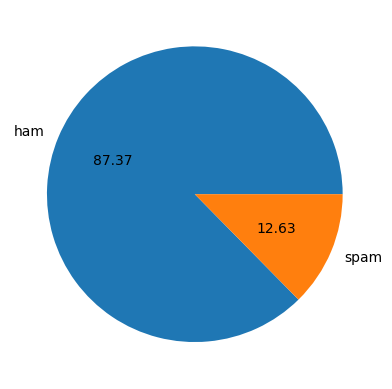

In [21]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.show()

data is imbalanced

we are going to find no of words, characters, sentences in the text

In [22]:
import nltk

In [23]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [24]:
#num of chars
df['num_characters']=df['text'].apply(len)
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [26]:
#num of words
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [27]:
#num of sentences
df['num_sentences']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
#ham
df[df['target'] ==0 ][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [30]:
#spam
df[df['target'] ==1 ][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


histogram for these classes

In [31]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

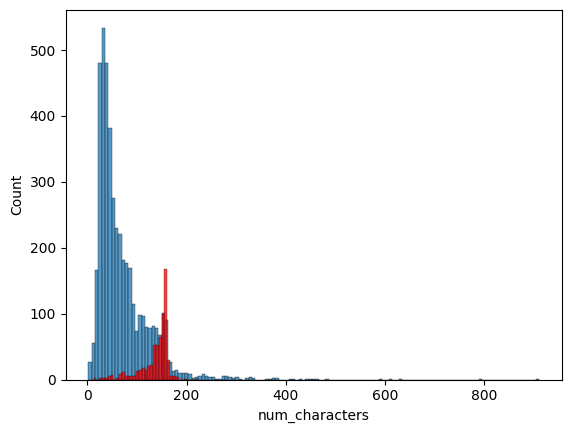

In [32]:
sns.histplot(df[df['target']==0]['num_characters'])
sns.histplot(df[df['target']==1]['num_characters'],color='red')

we can see that spam msg are having more number of characters whereas in ham msg , number of characters are less

<Axes: xlabel='num_words', ylabel='Count'>

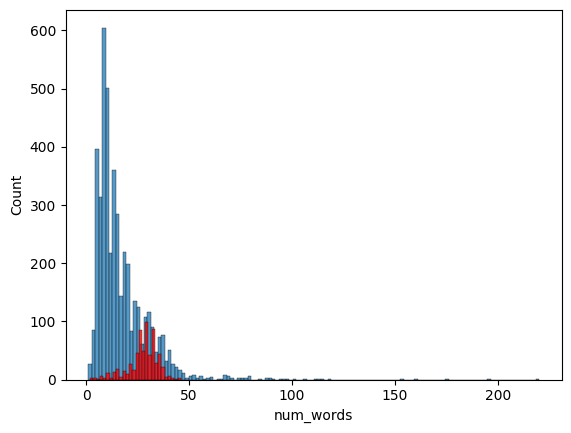

In [33]:
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

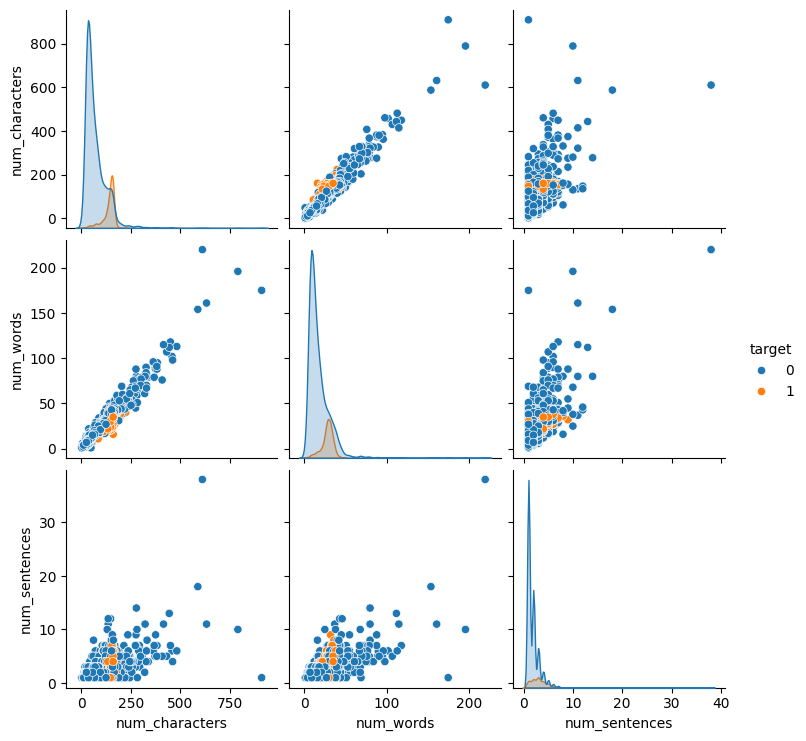

In [34]:
sns.pairplot(df,hue='target')

In [35]:
df[['target', 'num_characters', 'num_words', 'num_sentences']].corr()

,target,num_characters,num_words,num_sentences
target,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

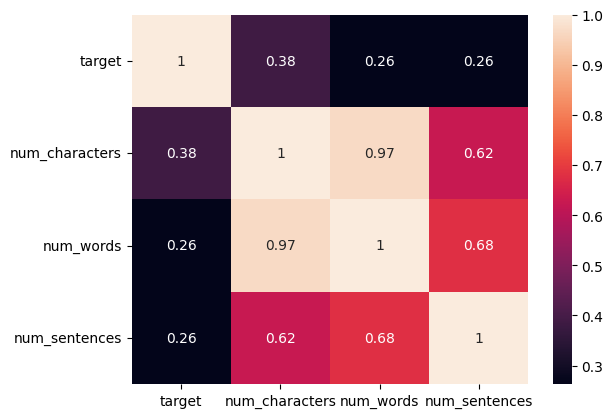

In [36]:
sns.heatmap(df[['target', 'num_characters', 'num_words', 'num_sentences']].corr(), annot=True)

we can see that num_words and num_sentences is having very high correlation with the target which is not good, so we will proceed with num_characters

**3. DATA PREPROCESSING**


*   lower case
*   tokenization


*   removing special characters
*   removing stop words (is, of, the etc) and punctuations





*   stemming (eg- danced, dancing= dance)








In [47]:
import string
def transform_text(text):
  text=text.lower()
  text= nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)

  text=y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text=y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [38]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [39]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
transform_text('did YOU like my ppt on ml?')

['like', 'ppt', 'ml']

In [41]:
transform_text('HI HOW ARE YOU 20%')

['hi', '20']

In [45]:
from nltk.stem.porter import PorterStemmer
ps= PorterStemmer()
ps.stem('dancing')
ps.stem('loved')

'love'

In [48]:
transform_text("i loved the yt lectures on machine learning")

'love yt lectur machin learn'

In [49]:
df['transformed_text']= df['text'].apply(transform_text)

In [50]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


now we will focus more on target and transformed_text

In [55]:
from wordcloud import WordCloud
wc= WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [58]:
spam_wc= wc.generate(df[df['target']==1] ['transformed_text'].str.cat(sep=" "))

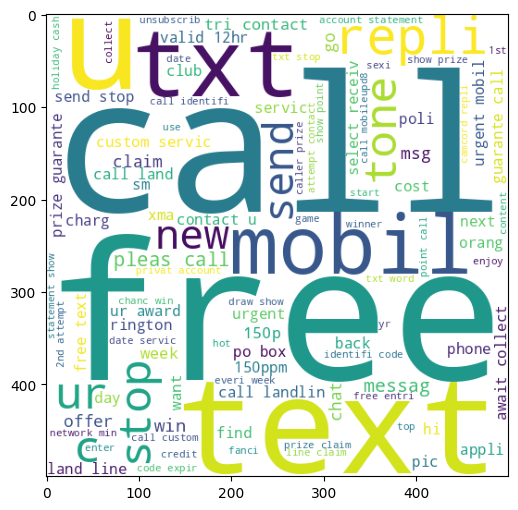

In [60]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

these are the most commonly used words in spam msg

In [62]:
spam_corpus=[]
for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)


In [63]:
len(spam_corpus)

9939

printing the most common words in spam msg

In [64]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

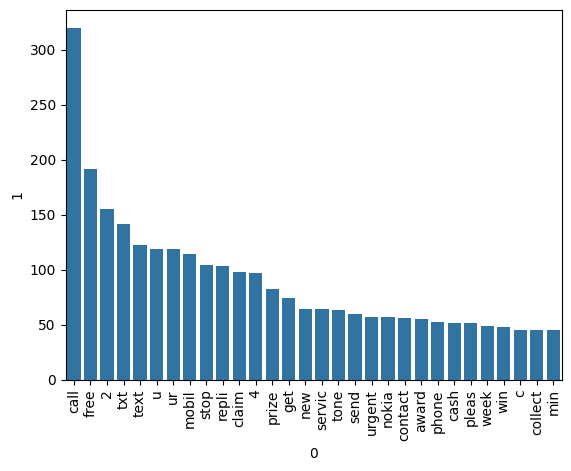

In [71]:
common_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=common_words_df[0], y=common_words_df[1])
plt.xticks(rotation='vertical')
plt.show()

**4. MODEL BUILDING**

using naive bayes as it is most suitable for textual data

In [104]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv= CountVectorizer()
tfidf= TfidfVectorizer(max_features=3000) #inorder to increase accuracy

In [105]:
x= tfidf.fit_transform(df['transformed_text']).toarray()

In [106]:
x.shape

(5169, 3000)

In [107]:
y=df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2, random_state=2)

In [110]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB


In [111]:
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()

In [112]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [113]:
gnb.fit(x_train,y_train)
y_pred1= gnb.predict(x_test)
print("output for gaussian NB")
print(f"Accuracy = {accuracy_score(y_test,y_pred1)*100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred1))
print(f"Precision = {precision_score(y_test,y_pred1)*100:.2f}%")

output for gaussian NB
Accuracy = 87.43%
Confusion Matrix:
 [[790 106]
 [ 24 114]]
Precision = 51.82%


we can see that the precision is low here which means it is only able to predict 53% correct spam msg

In [114]:
mnb.fit(x_train,y_train)
y_pred2= mnb.predict(x_test)
print("output for gaussian NB")
print(f"Accuracy = {accuracy_score(y_test,y_pred2)*100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred2))
print(f"Precision = {precision_score(y_test,y_pred2)*100:.2f}%")

output for gaussian NB
Accuracy = 97.10%
Confusion Matrix:
 [[896   0]
 [ 30 108]]
Precision = 100.00%


perfect precision score

In [115]:
bnb.fit(x_train,y_train)
y_pred3= bnb.predict(x_test)
print("output for gaussian NB")
print(f"Accuracy = {accuracy_score(y_test,y_pred3)*100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(y_test,y_pred3))
print(f"Precision = {precision_score(y_test,y_pred3)*100:.2f}%")

output for gaussian NB
Accuracy = 98.36%
Confusion Matrix:
 [[895   1]
 [ 16 122]]
Precision = 99.19%


since 100% precision is obtained in mnb , we will proceed with this

In [116]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl','wb'))

In [117]:
import sklearn
sklearn.__version__


'1.6.1'